In [1]:
import datetime as dt
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import os

In [75]:


# Load the JSON file
with open('piu26labels.json', 'r') as f:
    data = json.load(f)

# List to hold all interval records
records = []

# Iterate over tasks (each item in the top-level list)
for task in data:
    task_id = task.get('id')
    # Each task may have multiple annotations
    for ann in task.get('annotations', []):
        annotation_id = ann.get('id')
        for result in ann.get('result', []):
            value = result.get('value', {})
            start = value.get('start')
            end = value.get('end')
            labels = value.get('timeserieslabels', [])
            # Use first label or join if multiple
            label = labels[0] if labels else None
            
            records.append({
                'task_id': task_id,
                'annotation_id': annotation_id,
                'start': start,
                'end': end,
                'label': label,
                # Optionally include result id and origin
                'result_id': result.get('id'),
                'origin': result.get('origin')
            })

# Create DataFrame
df = pd.DataFrame(records)

# Convert start and end to datetime if desired
df['start'] = pd.to_datetime(df['start'])
df['end'] = pd.to_datetime(df['end'])

# Display
print(df.head())
print(f"\nTotal intervals extracted: {len(df)}")

   task_id  annotation_id               start                 end   label  \
0       13              5 2026-01-06 15:49:00 2026-01-06 16:05:00  Normal   
1       13              5 2026-01-06 16:05:00 2026-01-06 16:23:00  Normal   
2       13              5 2026-01-08 16:06:00 2026-01-08 16:26:00  Normal   
3       13              5 2026-01-08 16:48:00 2026-01-08 18:29:00  Normal   
4       13              5 2026-01-14 20:19:00 2026-01-14 21:24:00  Normal   

    result_id  origin  
0  DzI4_jevA4  manual  
1  Q1TRvm9_Xo  manual  
2  pynZph-LQ1  manual  
3  8ycifKWYDX  manual  
4  U3vA9p2mcb  manual  

Total intervals extracted: 90


In [77]:
df_labels = df.copy()

In [4]:
delta_tflare = (df["end"] - df["start"])#.dt.seconds
# delta_tflare_min =  
delta_tflare = delta_tflare.dt.total_seconds()/60

In [5]:
%matplotlib widget

In [5]:
plt.style.library

{'seaborn-v0_8-white': RcParams({'axes.axisbelow': True,
           'axes.edgecolor': '.15',
           'axes.facecolor': 'white',
           'axes.grid': False,
           'axes.labelcolor': '.15',
           'axes.linewidth': 1.25,
           'figure.facecolor': 'white',
           'font.family': ['sans-serif'],
           'font.sans-serif': ['Arial',
                               'Liberation Sans',
                               'DejaVu Sans',
                               'Bitstream Vera Sans',
                               'sans-serif'],
           'grid.color': '.8',
           'grid.linestyle': '-',
           'image.cmap': 'Greys',
           'legend.frameon': False,
           'legend.numpoints': 1,
           'legend.scatterpoints': 1,
           'lines.solid_capstyle': <CapStyle.round: 'round'>,
           'text.color': '.15',
           'xtick.color': '.15',
           'xtick.direction': 'out',
           'xtick.major.size': 0.0,
           'xtick.minor.size': 0.0,
     

In [6]:
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 100
})

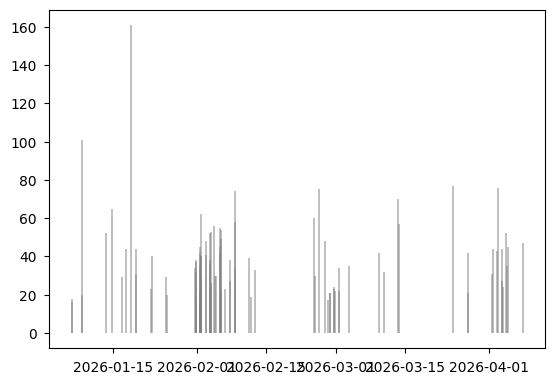

In [7]:
fig = plt.figure()
plt.plot(df["start"], delta_tflare, marker="x", lw=0, color="k")
plt.vlines(df["start"],0,  delta_tflare, color="gray", alpha=0.5)
# plt.steam(df["start"], delta_tflare)

<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_898253/3641602383.py:8: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('$\Delta t_{flare}$ (m)', fontsize=12)


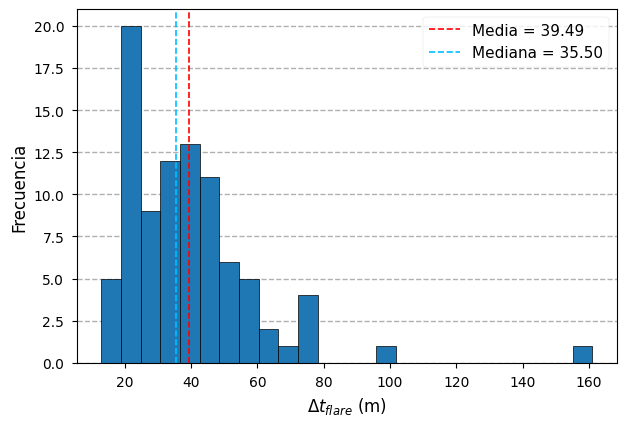

In [8]:
fig = plt.figure()#figsize=(4,3))
n, bins, patches = plt.hist(delta_tflare,bins=25, lw=0.5, edgecolor="k")
mean_val = np.mean(delta_tflare)
median_val = np.median(delta_tflare)
ax = plt.gca()
plt.axvline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'Media = {mean_val:.2f}')
plt.axvline(median_val, color='deepskyblue', linestyle='--', linewidth=1.2, label=f'Mediana = {median_val:.2f}')
plt.xlabel('$\Delta t_{flare}$ (m)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
# plt.title('distr', fontsize=14, fontweight='bold')
plt.grid(False)
plt.grid(axis="y", lw=1, ls="--")
ax.set_axisbelow(True) 
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [11]:
plt.close("all")

In [9]:
datadf = pd.DataFrame()
# for i in [1,2]:
#     _df = pd.read_csv(f"PIU_amp_dB_NAA_1min_2025_p{i}.csv", parse_dates=True, index_col=0)
#     datadf = pd.concat((datadf, _df))
datafiles = [
            'ANTAR_AMPLITUDE_2026-01-06-to-2026-02-01.csv',
            'ANTAR_AMPLITUDE_2026-02-01-to-2026-03-01.csv',
            # 'ANTAR_AMPLITUDE_2026-02-09-to-2026-03-05.csv',
            'ANTAR_AMPLITUDE_2026-03-01-to-2026-03-05.csv',
            'ANTAR_AMPLITUDE_2026-03-03-to-2026-04-01.csv',
            'ANTAR_AMPLITUDE_2026-04-01-to-2026-04-08.csv'
            ]

for  i in datafiles:
    datadf = pd.concat((datadf, pd.read_csv("/data/vlf/PIU/data/" + i, index_col=0, parse_dates=True)))
    # datadf = pd.read_csv("/data/vlf/PIU/data/" + i, index_col=0, parse_dates=True)
datadf = datadf.drop_duplicates()

In [10]:
datadf

,NPM,NAA,NLK,NLM,NAU,NPM-filt,NAA-filt,NLK-filt,NLM-filt,NAU-filt
2026-01-06 05:00:07,3.203410,1.084304,1.132410,1.135385,2.280181e-06,3.203410,1.084304,1.132410,1.135385,2.280181e-06
2026-01-06 05:00:17,3.006778,1.018855,1.131634,1.134155,3.063910e-06,3.167326,1.095861,1.125022,1.124720,2.703181e-06
2026-01-06 05:00:27,3.198742,1.090411,1.048174,1.037071,3.108185e-06,3.137835,1.105742,1.119848,1.116816,3.087220e-06
2026-01-06 05:00:36,3.203319,1.145672,1.159984,1.166493,2.749095e-06,3.119635,1.112833,1.118580,1.113763,3.403500e-06
2026-01-06 05:00:46,3.211128,1.100257,1.047577,1.044662,2.977108e-06,3.114186,1.116946,1.122001,1.116482,3.640542e-06
...,...,...,...,...,...,...,...,...,...,...
2026-04-08 04:59:03,1.159459,0.201362,0.980911,0.977269,8.490061e-07,1.170989,0.280184,1.016064,1.017419,1.533435e-06
2026-04-08 04:59:13,1.125279,0.202849,1.014875,1.015485,1.083762e-06,1.161910,0.271618,1.030051,1.031503,1.405367e-06
2026-04-08 04:59:22,1.146341,0.237563,0.923467,0.913599,1.569076e-06,1.148479,0.267118,1.043540,1.045256,1.236745e-06
2026-04-08 04:59:32,1.260778,0.273809,1.033369,1.036540,1.496972e-06,1.131866,0.266815,1.055827,1.057973,1.039316e-06


In [64]:
datadf["state"] = np.zeros(len(datadf))
datadf = datadf["NAA-filt"].resample("1min").mean()
datadf.head()

2026-01-05 00:00:00   NaN
2026-01-05 00:01:00   NaN
2026-01-05 00:02:00   NaN
2026-01-05 00:03:00   NaN
2026-01-05 00:04:00   NaN
Freq: min, Name: NAA-filt, dtype: float64

In [16]:
import sys
sys.path.append("/home/diace/pavnet-v3/vlfcode/")
# from sxrf_download import sunpy_xrf as xr
import swlaspdata as sw

In [17]:
df.head()

,task_id,annotation_id,start,end,label,result_id,origin
0,13,5,2026-01-06 15:49:00,2026-01-06 16:05:00,Normal,DzI4_jevA4,manual
1,13,5,2026-01-06 16:05:00,2026-01-06 16:23:00,Normal,Q1TRvm9_Xo,manual
2,13,5,2026-01-08 16:06:00,2026-01-08 16:26:00,Normal,pynZph-LQ1,manual
3,13,5,2026-01-08 16:48:00,2026-01-08 18:29:00,Normal,8ycifKWYDX,manual
4,13,5,2026-01-14 20:19:00,2026-01-14 21:24:00,Normal,U3vA9p2mcb,manual


In [19]:
x=1

In [20]:
# sw.goes_satellite=18
sw.datasets["xray_flux_template"] = "dap/noaa_goes_xrs_1m_template"
# sw.datasets["xray_flux_template"] = "noaa_goes_xrs_1m_template"
df = sw.get_data("dap/noaa_goes19_xrs_1m", "2026-01-06","2026-04-08")

Error downloading dap/noaa_goes19_xrs_1m: <urlopen error [Errno 110] Connection timed out>
URL: https://lasp.colorado.edu/space-weather-portal/latis/dap/noaa_goes19_xrs_1m.csv?time%3E=2026-01-06&time%3C2026-04-08


In [120]:
# df = pd.read_csv("XrayFlux_2026-01-05 00:00:00_to_2026-04-08 23:00:00.csv", parse_dates=True, index_col=0)
df = pd.read_csv("noaa_goes19_xrs_1m (1).csv",)# parse_dates=True, index_col=0)

df.head(2)

,time (seconds since 2000-01-01 12:00:00),shortwave (W/m^2),longwave (W/m^2),shortwave_flag,longwave_flag,shortwave_masked (W/m^2),longwave_masked (W/m^2)
0,820929600.0,2.108886e-08,9.863842e-07,0,0,2.108886e-08,9.863842e-07
1,820929660.0,2.134709e-08,9.882515e-07,0,0,2.134709e-08,9.882515e-07


In [121]:
# formatting the time index column
t_ = [ dt.datetime(2000, 1,1, 12) + dt.timedelta(seconds=i) for i in df["time (seconds since 2000-01-01 12:00:00)"].values]

goes19 = df["longwave_masked (W/m^2)"]
t_ = [dt.datetime(2000,1,1,12) + dt.timedelta(seconds=i) 
      for i in df["time (seconds since 2000-01-01 12:00:00)"]]
goes19.index = t_

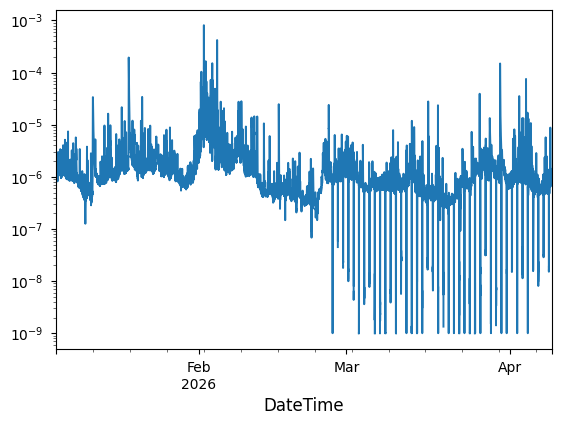

In [26]:
fig = plt.figure()
ax = plt.subplot()
df["GOES-18_long"].plot(x="DateTime")
ax.set_yscale("log")
plt.show()

In [128]:
plt.close()

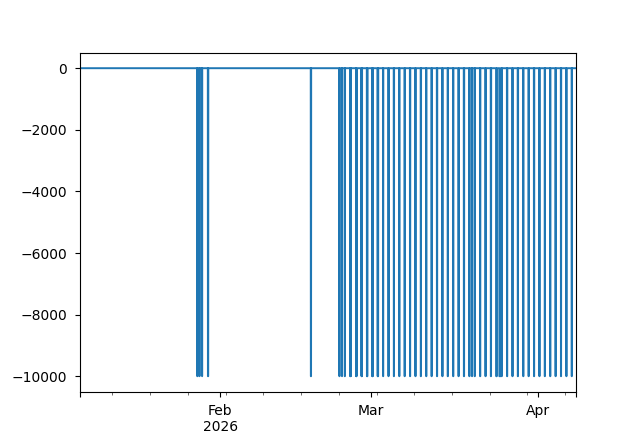

In [129]:
fig = plt.figure()
goes19.plot()
plt.show()


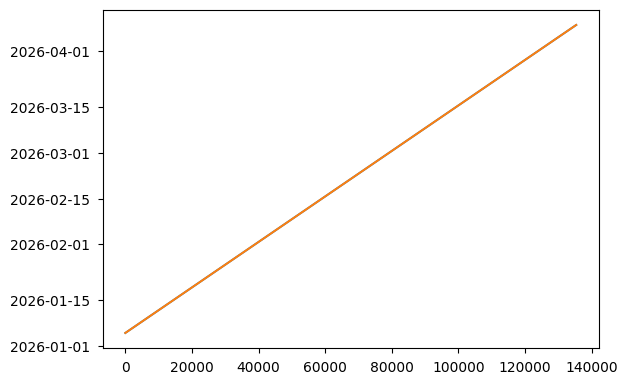

In [65]:
plt.plot(datadf.index)
plt.plot( df.index)

In [157]:
print("datadf has duplicates:", datadf.index.has_duplicates)
print("goes19 has duplicates:", goes19.index.has_duplicates)

datadf has duplicates: True
goes19 has duplicates: False


In [28]:
goes18

DateTime
2026-01-05 00:00:00    9.073950e-07
2026-01-05 00:01:00    9.081370e-07
2026-01-05 00:02:00    9.064640e-07
2026-01-05 00:03:00    9.074515e-07
2026-01-05 00:04:00    9.117205e-07
                           ...     
2026-04-08 23:55:00    1.191676e-06
2026-04-08 23:56:00    1.139580e-06
2026-04-08 23:57:00    1.101085e-06
2026-04-08 23:58:00    1.078067e-06
2026-04-08 23:59:00    1.056329e-06
Name: GOES-18_long, Length: 135360, dtype: float64

In [130]:
# datadf.drop(c|olumns =["GOES19"])
datadf = datadf[~datadf.index.duplicated(keep='first')]
# goes18 = df[["GOES-18_long"]] 
goes19 = goes19[~goes19.index.duplicated(keep='first')]
# goes18 = goes18[~goes18.index.duplicated(keep='first')]

# Now concatenate
datadf = pd.concat((datadf, goes19), axis=1, sort=True)

In [37]:
goes18.index.dtype

dtype('<M8[us]')

In [43]:
datadf.drop(columns="GOES-18_long", inplace=True)

In [135]:
# datadf["GOES18"] = df["GOES-18_long"]
datadf.rename(columns={"longwave_masked (W/m^2)":"GOES19"}, inplace=True)

In [136]:
datadf.head()

,NAA,GOES-18_long,GOES18,state,GOES19
2026-01-05 00:00:00,NaN,9.073950e-07,9.073950e-07,0,NaN
2026-01-05 00:01:00,NaN,9.081370e-07,9.081370e-07,0,NaN
2026-01-05 00:02:00,NaN,9.064640e-07,9.064640e-07,0,NaN
2026-01-05 00:03:00,NaN,9.074515e-07,9.074515e-07,0,NaN
2026-01-05 00:04:00,NaN,9.117205e-07,9.117205e-07,0,NaN


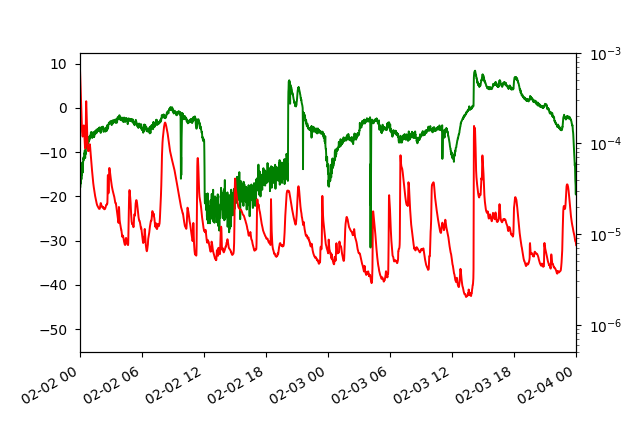

In [137]:
fig = plt.figure()
ax = plt.gca()
ax.plot(datadf[["NAA"]], color="g")
ax2 = ax.twinx()
ax2.plot(datadf[["GOES19"]],color="r")
# ax2.plot(datadf[["GOES18"]],color="r")
ax2.set_ylim(5e-7,1e-3)
ax2.set_yscale("log")
ax.set_xlim(dt.datetime(2026,2,2), dt.datetime(2026,2,4
                                              ))
fig.autofmt_xdate()
plt.show()

In [160]:
%matplotlib inline
datadf.rename(columns={"longwave (W/m^2)": 'GOES19'}, inplace=True)
datadf

,NAA,GOES18,state,GOES19
2024-12-17 00:00:00,NaN,NaN,NaN,0.000002
2024-12-17 00:01:00,NaN,NaN,NaN,0.000002
2024-12-17 00:02:00,NaN,NaN,NaN,0.000002
2024-12-17 00:03:00,NaN,NaN,NaN,0.000002
2024-12-17 00:04:00,NaN,NaN,NaN,0.000002
...,...,...,...,...
2026-01-06 04:55:00,1.252027,0.000002,0.0,NaN
2026-01-06 04:56:00,1.171363,0.000001,0.0,NaN
2026-01-06 04:57:00,1.106434,0.000001,0.0,NaN
2026-01-06 04:58:00,1.198408,0.000001,0.0,NaN


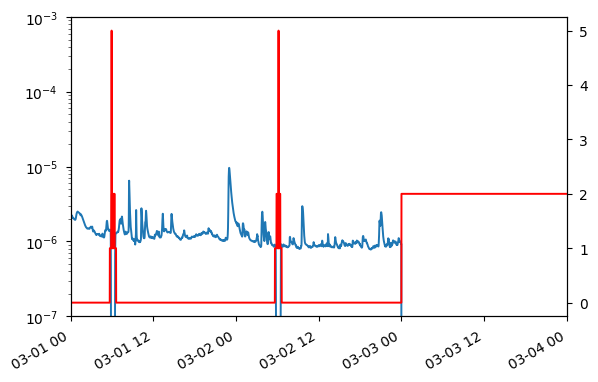

In [165]:
fig = plt.figure()
ax = plt.subplot()
plt.plot(df["GOES18"])

plt.ylim(1e-7, 1e-3)
plt.yscale("log")
ax2 = ax.twinx()
ax2.plot(goes19["longwave_flag"], color="r")
ax2.set_xlim(dt.datetime(2025, 3,1), dt.datetime(2025, 3,4))
fig.autofmt_xdate()

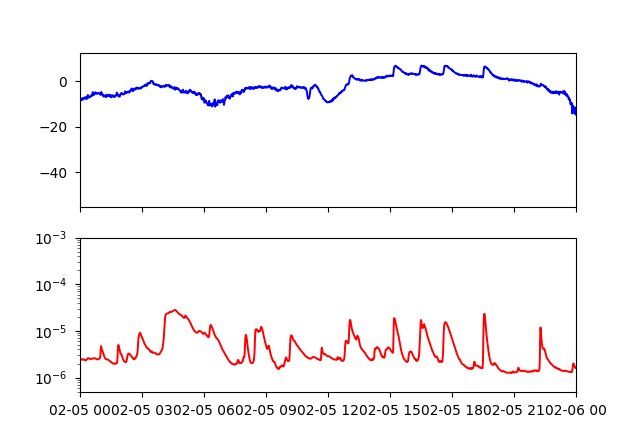

In [139]:
# datadf["GOES19"].shape , goes19.shape
fig, (ax1,ax2)= plt.subplots(2, sharex=True)
ax1.plot(datadf["NAA"], color="blue")
ax2.plot(datadf["GOES19"], color="red")
plt.xlim(dt.datetime(2026,2,5), dt.datetime(2026, 2,6))
ax2.set_ylim(5e-7, 1e-3)
ax2.set_yscale("log")
plt.show()

In [181]:
def flareclass(flux):
    if 1e-7<= flux < 1e-6: return "B"
    elif 1e-6<= flux < 1e-5: return "C"
    elif 1e-5<= flux < 1e-4: return "M"
    elif 1e-4<= flux < 1e-3: return "X"
    else: return "NN"

In [183]:
# vamos a etiquetar estados en una columna del df de los datos de amplitud y xrays (datadf)
# vamos rango 	time (seconds since 2000-01-01 12:00:00) tras rango del df de etiquetas (df)
# fig = plt.figure()
peakdf = pd.DataFrame() 	

#k=0
for k, (r0, rf) in enumerate(df_labels.loc[:, ["start", "end"]].values):
    #print(r0,rf)
    _wdf = datadf.loc[r0:rf, ["NAA", "GOES19"]]
    try:
        # x ray flux
        ii_vlf = _wdf["NAA"].argmax()
        df_labels.loc[k, "middle"] = _wdf["NAA"].index[ii_vlf] # change point between onset and decay
        peak_amp = _wdf["NAA"].iloc[ii_vlf]  # grab the window within the time labeled
        peak_time = _wdf.index[ii_vlf]
        peakdf.loc[k, ["amp_peak_time", "peak_amp"]] = [peak_time, peak_amp]
        
        # amplitude / vlf signal
        ii = _wdf["GOES19"].argmax()
        peak_flux = _wdf["GOES19"].iloc[ii]  # grab the window within the time labeled
        peak_time = _wdf.index[ii]
        peakdf.loc[k, ["flux_peak_time", "peak_flux"]] = [peak_time, peak_flux]
        df_labels.loc[k, "flare_class"] = flareclass(peak_flux)
    except Exception as e:
        print(k, peak_time)
        print(e)
    # peakdf.loc[peak_time, "peak_amp"] = peak_amp
    # print(y)
    # plt.plot(y)
    # _wdf.plot(marker="o")
    # break

In [184]:
df_labels

,task_id,annotation_id,start,end,label,result_id,origin,middle,flare_class
0,13,5,2026-01-06 15:49:00,2026-01-06 16:05:00,Normal,DzI4_jevA4,manual,2026-01-06 16:00:00,C
1,13,5,2026-01-06 16:05:00,2026-01-06 16:23:00,Normal,Q1TRvm9_Xo,manual,2026-01-06 16:12:00,C
2,13,5,2026-01-08 16:06:00,2026-01-08 16:26:00,Normal,pynZph-LQ1,manual,2026-01-08 16:10:00,C
3,13,5,2026-01-08 16:48:00,2026-01-08 18:29:00,Normal,8ycifKWYDX,manual,2026-01-08 17:30:00,C
4,13,5,2026-01-14 20:19:00,2026-01-14 21:24:00,Normal,U3vA9p2mcb,manual,2026-01-14 20:38:00,M
...,...,...,...,...,...,...,...,...,...
85,13,5,2026-04-04 12:00:00,2026-04-04 12:52:00,Normal,QO3wfEfDzb,manual,2026-04-04 12:12:00,M
86,13,5,2026-04-04 17:05:00,2026-04-04 17:40:00,Normal,brx4QMkUGX,manual,2026-04-04 17:15:00,C
87,13,5,2026-04-04 19:36:00,2026-04-04 20:21:00,Normal,cubn5H68GU,manual,2026-04-04 19:44:00,C
88,13,5,2026-04-07 18:19:00,2026-04-07 19:06:00,Normal,3Kje622C1F,manual,2026-04-07 18:31:00,C


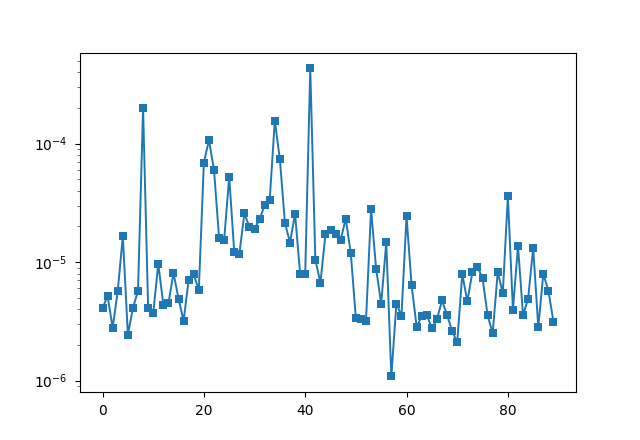

In [141]:
fig = plt.figure()
peakdf["peak_flux"].plot(marker="s")
plt.yscale("log")
plt.show()

In [154]:
len(peakdf)

90

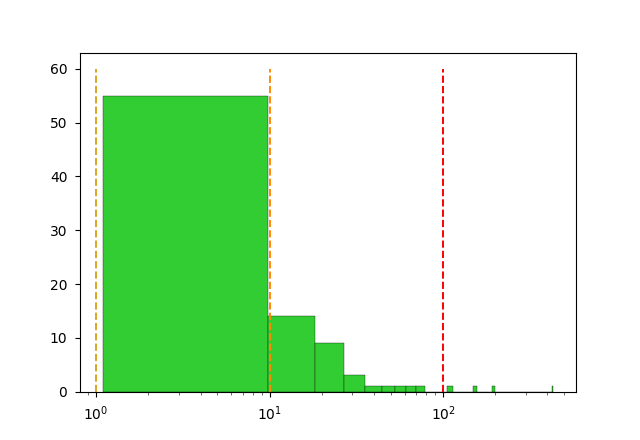

In [174]:
flare_Ctype_lim = 1e-6 * 1e6 # * 1e6 to have uW/m²
flare_Mtype_lim = 1e-5 * 1e6
flare_Xtype_lim = 1e-4 * 1e6

fig = plt.figure()
plt.hist(peakdf["peak_flux"]*1000000,bins=50,  color="limegreen", edgecolor="black")
plt.xscale("log")
plt.vlines([flare_Ctype_lim, flare_Mtype_lim, flare_Xtype_lim], 0,60, ls="--", colors=["goldenrod", "darkorange", "red"])
plt.show()

In [156]:
plt.close()

In [160]:
peakdf = peakdf.sort_index()
#peakdf_clean = peakdf[peakdf["peak_flux"]>-1]

        
peakdf["flare_class"] = peakdf["peak_flux"].apply(flareclass)
print(peakdf)


         amp_peak_time  peak_amp      flux_peak_time  peak_flux flare_class
0  2026-01-06 16:00:00  2.616822 2026-01-06 15:55:00   0.000004           C
1  2026-01-06 16:12:00  3.069475 2026-01-06 16:09:00   0.000005           C
2  2026-01-08 16:10:00  2.742319 2026-01-08 16:09:00   0.000003           C
3  2026-01-08 17:30:00  3.471707 2026-01-08 17:30:00   0.000006           C
4  2026-01-14 20:38:00  4.794696 2026-01-14 20:33:00   0.000017           M
..                 ...       ...                 ...        ...         ...
85 2026-04-04 12:12:00  1.353936 2026-04-04 12:11:00   0.000013           M
86 2026-04-04 17:15:00  4.317264 2026-04-04 17:15:00   0.000003           C
87 2026-04-04 19:44:00  5.212724 2026-04-04 19:47:00   0.000008           C
88 2026-04-07 18:31:00  5.755010 2026-04-07 18:32:00   0.000006           C
89 2026-02-11 19:49:00  2.505881 2026-02-11 19:48:00   0.000003           C

[90 rows x 5 columns]


In [166]:
peakdf["flare_class"].value_counts()

flare_class
C    55
M    31
X     4
Name: count, dtype: int64

Text(0.5, 0, 'Xray Flux at Peak')

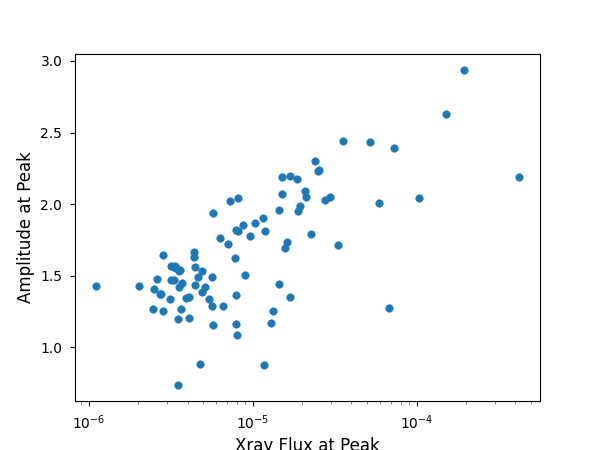

In [167]:
ifg = plt.figure(figsize=(6, 4.5))
ax= plt.subplot()
plt.scatter(peakdf_clean["peak_flux"].values, peakdf_clean["peak_amp"].values,)# lw=0, markeredgecolor="darkred", markerfacecolor="none")
# plt.plot(peakdf["peak_flux"])
ax.set_xscale("log")
ax.set_ylabel("Amplitude at Peak")
ax.set_xlabel("Xray Flux at Peak")

In [177]:
df

,time (seconds since 2000-01-01 12:00:00),shortwave (W/m^2),longwave (W/m^2),shortwave_flag,longwave_flag,shortwave_masked (W/m^2),longwave_masked (W/m^2),middle
0,820929600.0,2.108886e-08,9.863842e-07,0,0,2.108886e-08,9.863842e-07,2026-01-06 16:00:00
1,820929660.0,2.134709e-08,9.882515e-07,0,0,2.134709e-08,9.882515e-07,2026-01-06 16:12:00
2,820929720.0,2.096299e-08,9.904509e-07,0,0,2.096299e-08,9.904509e-07,2026-01-08 16:10:00
3,820929780.0,2.089132e-08,9.963433e-07,0,0,2.089132e-08,9.963433e-07,2026-01-08 17:30:00
4,820929840.0,2.135903e-08,9.988120e-07,0,0,2.135903e-08,9.988120e-07,2026-01-14 20:38:00
...,...,...,...,...,...,...,...,...
132475,828878100.0,4.650924e-08,1.007180e-06,0,0,4.650924e-08,1.007180e-06,NaT
132476,828878160.0,4.501715e-08,9.786800e-07,0,0,4.501715e-08,9.786800e-07,NaT
132477,828878220.0,4.230494e-08,9.492778e-07,0,0,4.230494e-08,9.492778e-07,NaT
132478,828878280.0,3.903111e-08,9.226703e-07,0,0,3.903111e-08,9.226703e-07,NaT


In [185]:
datadf.loc[:, "state"] = 0 #np.zeros(len())
for k, (ti, tm, tf, c) in enumerate(df_labels.loc[:,["start", "middle", "end", "flare_class"]].values):
    datadf.loc[ti:tm, "state"] = 1 # onset state (from start till peak)
    datadf.loc[tm:tf, "state"] = 2 # onset state (from middle (peak) till end (return to normal))
    datadf.loc[ti:tf, "flare_class"] = c

In [89]:
%matplotlib widget

In [ ]:
datadf["NAA"] = 20*np.log10(datadf["NAA"])

In [187]:
datadf.head()

,NAA,GOES-18_long,GOES18,state,GOES19,flare_class
2026-01-05 00:00:00,NaN,9.073950e-07,9.073950e-07,0,NaN,NaN
2026-01-05 00:01:00,NaN,9.081370e-07,9.081370e-07,0,NaN,NaN
2026-01-05 00:02:00,NaN,9.064640e-07,9.064640e-07,0,NaN,NaN
2026-01-05 00:03:00,NaN,9.074515e-07,9.074515e-07,0,NaN,NaN
2026-01-05 00:04:00,NaN,9.117205e-07,9.117205e-07,0,NaN,NaN


In [188]:
datadf.to_csv("vlf_test_2026_piu.csv", index=True)

In [92]:
datatrain = pd.read_csv("vlf_trainingdata_2025_piu.csv", index_col=0, parse_dates=True
                       )

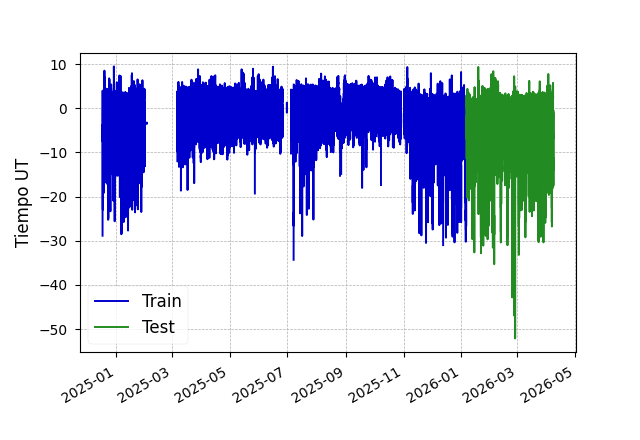

In [186]:
fig,ax = plt.subplots()
ax.plot(datatrain["NAA"], color="mediumblue", label="Train")
ax.plot(datadf["NAA"], color="forestgreen", label="Test")
# ax.set_xlim(left=dt.datetime(2026,1,4), right=dt.datetime(2026,1,7))
# ax.set_xlim(left=dt.datetime(2026,1,4))
ax.set_ylabel("Amplitud (dB)")
ax.set_ylabel("Tiempo UT")
ax.legend(loc="lower left", fontsize=12)
ax.grid(ls="--", lw=0.5)
fig.autofmt_xdate()
plt.show()

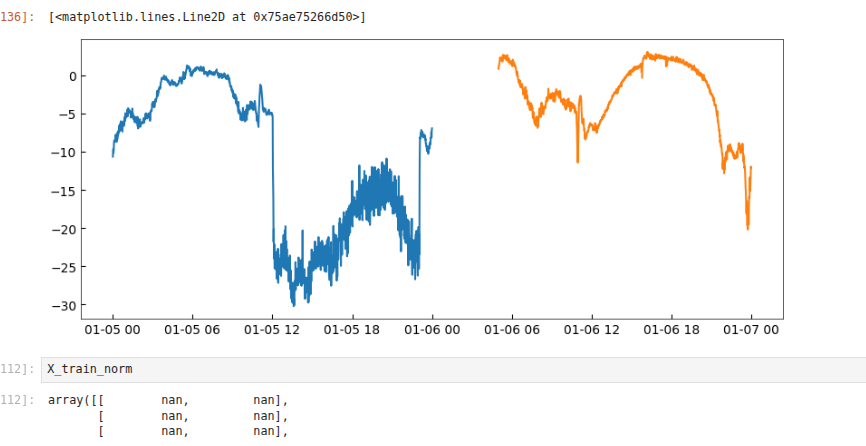

In [108]:
plt.close("all")

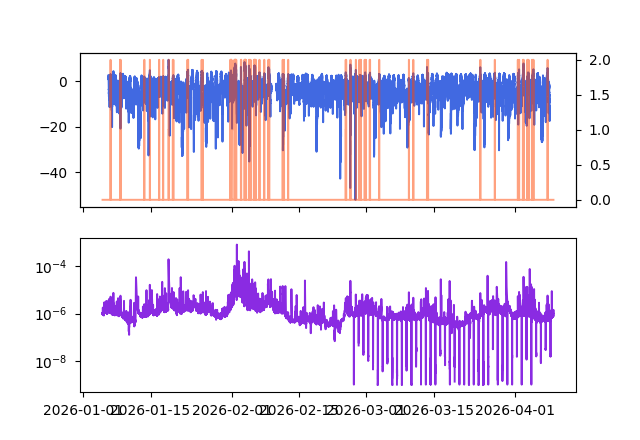

In [112]:
fig, axs = plt.subplots(2, sharex=True)
axs[0].plot(datadf["NAA"], color="royalblue") #.plot(ax=axs[0])
_ax = axs[0].twinx()
_ax.step(datadf.index, datadf["state"], color="orangered", alpha=0.5)
axs[1].plot(datadf["GOES18"], color="blueviolet")#.plot(color="r",ax=axs[1])
axs[1].set_yscale("log")
axs[1].set_ylabel("Flujo (W/m²)")
plt.show()

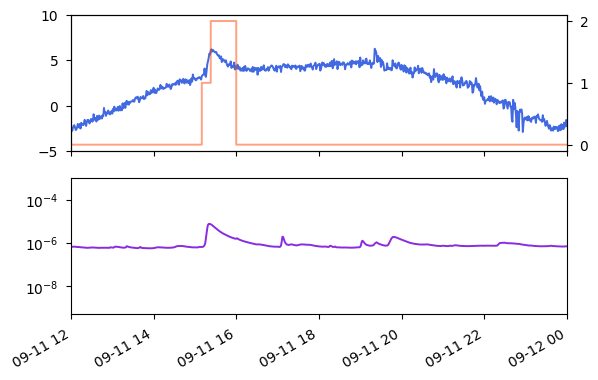

In [195]:
fig, axs = plt.subplots(2, sharex=True)
axs[0].plot(datadf["NAA"], color="royalblue") #.plot(ax=axs[0])
axs[0].set_ylim(-5,10)
_ax = axs[0].twinx()
_ax.step(datadf.index, datadf["state"], color="orangered", alpha=0.5)
axs[1].plot(datadf["GOES18"], color="blueviolet")#.plot(color="r",ax=axs[1])
axs[1].set_yscale("log")
_ax.set_xlim(dt.datetime(2025, 9,11,12), dt.datetime(2025, 9,12))
fig.autofmt_xdate()
plt.show()

### Distribution by energy/flare type

<>:5: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:7: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:5: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:7: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_122254/1026951725.py:5: SyntaxWarning: "\l" is an invalid escape se

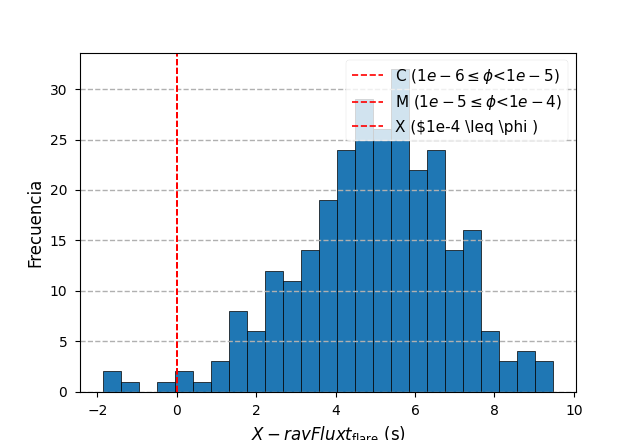

In [31]:
fig = plt.figure()#figsize=(4,3)) 	time (seconds since 2000-01-01 12:00:00)
n, bins, patches = plt.hist(peakdf.values,bins=25, lw=0.5, edgecolor="k")
mean_val = np.mean(peakdf.values)
median_val = np.median(peakdf.values)
plt.axvline(1e-6, color='red', linestyle='--', linewidth=1.2, label=f'C ($1e-6 \leq \phi \less 1e-5 $)')
plt.axvline(1e-5, color='red', linestyle='--', linewidth=1.2, label=f'M ($1e-5 \leq \phi \less 1e-4 $)')
plt.axvline(1e-4, color='red', linestyle='--', linewidth=1.2, label=f'X ($1e-4 \leq \phi )')
# plt.axvline(1e-5, color='deepskyblue', linestyle='--', linewidth=1.2, label=f'Mediana = {median_val:.2f}')
plt.xlabel(r'$X-ray Flux t_{\mathrm{flare}}$ (s)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
# plt.title('distr', fontsize=14, fontweight='bold')
plt.grid(False)
plt.grid(axis="y", lw=1, ls="--")
plt.legend(fontsize=11)

<Axes: >

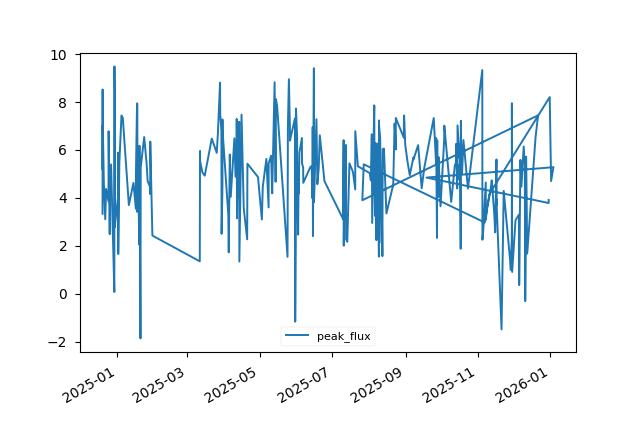

In [32]:
peakdf.plot()

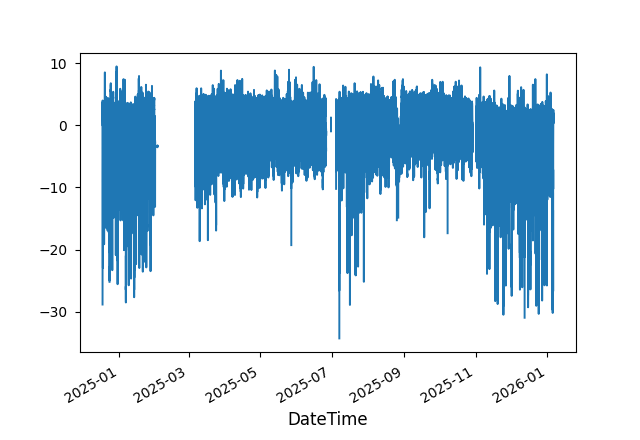

In [24]:
fig, ax = plt.subplots()
datadf["NAA"].plot(ax=ax)
plt.show()

In [53]:
df.loc[:, ["start", "end"]].values

array([['2024-12-19T13:44:00.000000', '2024-12-19T14:23:00.000000'],
       ['2024-12-19T14:23:00.000000', '2024-12-19T15:01:00.000000'],
       ['2024-12-19T15:02:00.000000', '2024-12-19T15:25:00.000000'],
       ['2024-12-19T15:23:00.000000', '2024-12-19T16:29:00.000000'],
       ['2024-12-19T17:01:00.000000', '2024-12-19T17:47:00.000000'],
       ['2024-12-19T17:47:00.000000', '2024-12-19T18:43:00.000000'],
       ['2024-12-19T18:54:00.000000', '2024-12-19T19:42:00.000000'],
       ['2024-12-20T16:43:00.000000', '2024-12-20T17:12:00.000000'],
       ['2024-12-21T20:30:00.000000', '2024-12-21T20:56:00.000000'],
       ['2024-12-22T14:01:00.000000', '2024-12-22T14:49:00.000000'],
       ['2024-12-24T14:02:00.000000', '2024-12-24T14:38:00.000000'],
       ['2024-12-24T15:07:00.000000', '2024-12-24T15:54:00.000000'],
       ['2024-12-24T16:27:00.000000', '2024-12-24T17:19:00.000000'],
       ['2024-12-24T18:17:00.000000', '2024-12-24T18:51:00.000000'],
       ['2024-12-25T15:06:00.00000

### test data

In [7]:
#files = ["/data/vlf/PIU/data/"]
r = "/data/vlf/PIU/data/"
files = [os.path.join(r, x) for x in os.listdir(r) if x.startswith("ANTAR")]
files

['/data/vlf/PIU/data/ANTAR_AMPLITUDE_2026-01-06-to-2026-02-01.csv',
 '/data/vlf/PIU/data/ANTAR_AMPLITUDE_2026-04-01-to-2026-04-08.csv',
 '/data/vlf/PIU/data/ANTAR_AMPLITUDE_2026-02-01-to-2026-03-01.csv',
 '/data/vlf/PIU/data/ANTAR_AMPLITUDE_2026-03-03-to-2026-04-01.csv']

In [9]:
testdf = pd.DataFrame()
for f in files:
    _df = pd.read_csv(f, parse_dates=True, index_col=0)
    testdf = pd.concat((testdf, _df))

testdf = testdf.sort_index()
testdf

,NPM,NAA,NLK,NLM,NAU,NPM-filt,NAA-filt,NLK-filt,NLM-filt,NAU-filt
2026-01-06 05:00:07,3.203410,1.084304,1.132410,1.135385,2.280181e-06,3.203410,1.084304,1.132410,1.135385,2.280181e-06
2026-01-06 05:00:17,3.006778,1.018855,1.131634,1.134155,3.063910e-06,3.167326,1.095861,1.125022,1.124720,2.703181e-06
2026-01-06 05:00:27,3.198742,1.090411,1.048174,1.037071,3.108185e-06,3.137835,1.105742,1.119848,1.116816,3.087220e-06
2026-01-06 05:00:36,3.203319,1.145672,1.159984,1.166493,2.749095e-06,3.119635,1.112833,1.118580,1.113763,3.403500e-06
2026-01-06 05:00:46,3.211128,1.100257,1.047577,1.044662,2.977108e-06,3.114186,1.116946,1.122001,1.116482,3.640542e-06
...,...,...,...,...,...,...,...,...,...,...
2026-04-08 04:59:03,1.159459,0.201362,0.980911,0.977269,8.490061e-07,1.170989,0.280184,1.016064,1.017419,1.533435e-06
2026-04-08 04:59:13,1.125279,0.202849,1.014875,1.015485,1.083762e-06,1.161910,0.271618,1.030051,1.031503,1.405367e-06
2026-04-08 04:59:22,1.146341,0.237563,0.923467,0.913599,1.569076e-06,1.148479,0.267118,1.043540,1.045256,1.236745e-06
2026-04-08 04:59:32,1.260778,0.273809,1.033369,1.036540,1.496972e-06,1.131866,0.266815,1.055827,1.057973,1.039316e-06


In [10]:
testdf = testdf["NAA"].resample("1min").mean()

(29505600.0, 29508480.0)

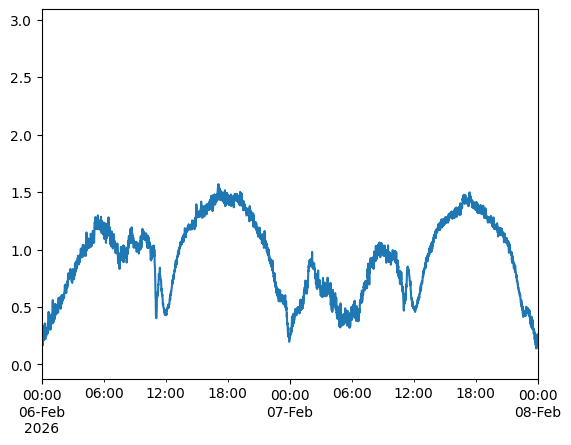

In [14]:
fig, ax = plt.subplots()
testdf.plot(ax=ax)
ax.set_xlim(dt.datetime(2026,2,6), dt.datetime(2026,2,8))